<a href="https://colab.research.google.com/github/KomalLamba/Data-Driven-Analysis-for-User-Behavior--Fraud-Detection--and-Revenue-Insights/blob/main/Transaction_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Python Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

Data loading

In [11]:
df = pd.read_csv('1_txn_data.csv')

In [12]:
df.shape

(65936, 13)

In [27]:
df.head()

,adv_id,value_in_paise,payment_gateway,payment_method,payment_status,created_at,app_id,from_currency_amount,from_currency,to_currency_amount,to_currency,transaction_fee_amount,transaction_fee_currency
0,NaN,3000,RAZORPAY,UPI,PROCESSED,2024-10-18 09:34:14.247708+00:00,sikka,300.0,sikka,30.0,INR,130.0,paise
1,2d3ad81b-a068-460a-9f35-60d7df3c2b78,3000,RAZORPAY,UPI,PROCESSED,2024-10-18 09:34:14.247708+00:00,sikka,300.0,sikka,30.0,INR,130.0,paise
2,3052eb57-f48d-4bb5-9469-bf4e1c71c8a9,3000,RAZORPAY,UPI,PROCESSED,2024-10-18 09:34:14.247708+00:00,sikka,300.0,sikka,30.0,INR,130.0,paise
3,802684aa-0870-4258-9561-aa84f6aa88d8,3000,RAZORPAY,UPI,PROCESSED,2024-10-18 09:34:14.247708+00:00,sikka,300.0,sikka,30.0,INR,130.0,paise
4,92edbd60-5179-47ca-bb6d-122a157a27e0,3000,RAZORPAY,UPI,PROCESSED,2024-10-18 09:34:14.247708+00:00,sikka,300.0,sikka,30.0,INR,130.0,paise


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65936 entries, 0 to 65935
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   adv_id                    65914 non-null  object             
 1   value_in_paise            65936 non-null  int64              
 2   payment_gateway           65936 non-null  object             
 3   payment_method            65936 non-null  object             
 4   payment_status            65936 non-null  object             
 5   created_at                65936 non-null  datetime64[ns, UTC]
 6   app_id                    65936 non-null  object             
 7   from_currency_amount      65936 non-null  float64            
 8   from_currency             65936 non-null  object             
 9   to_currency_amount        65936 non-null  float64            
 10  to_currency               65936 non-null  object             
 11  transaction_fee

Analyse Data

In [37]:
df['created_at'] = pd.to_datetime(df['created_at'])
df_success = df[df['payment_status'] == 'PROCESSED'].copy()
df_success = df_success.sort_values(['adv_id', 'created_at'])
df_success['transaction_sequence'] = df_success.groupby('adv_id').cumcount() + 1


Analyse Transactions

In [39]:
first_txns = df_success[df_success['transaction_sequence'] == 1].copy()
second_txns = df_success[df_success['transaction_sequence'] == 2].copy()

time_to_second = first_txns.merge(
    second_txns[['adv_id', 'created_at']],
    on='adv_id',
    suffixes=('_first', '_second')
)

time_to_second['time_diff_days'] = (
    time_to_second['created_at_second'] - time_to_second['created_at_first']
).dt.total_seconds() / (3600 * 24)

avg_time_days = time_to_second['time_diff_days'].mean()
median_time_days = time_to_second['time_diff_days'].median()

print(f"Average Time to 2nd Purchase: {avg_time_days :.2f} days")


Average Time to 2nd Purchase: 1.64 days


In [24]:
total_users = len(first_txns)
returning_users = len(second_txns)
retention_rate = (returning_users / total_users) * 100

print(f"Retention Rate: {retention_rate:.2f}%")

Retention Rate: 23.92%


In [25]:
subsequent_txns = df_success[df_success['transaction_sequence'] > 1].copy()
avg_subsequent_amount = subsequent_txns['value_in_paise'].mean()

print(f"Avg Amount Spent after 1st purchase: {avg_subsequent_amount:.2f} paise")

Avg Amount Spent after 1st purchase: 5217.67 paise


In [41]:
first_count = len(first_txns)
sequence_counts = df_success['transaction_sequence'].value_counts().sort_index().head(10)
funnel_data = sequence_counts.tolist()
funnel_labels = [f"Txn {i}" for i in range(1, len(funnel_data) + 1)]



Visualisation

/tmp/ipykernel_21638/2723598356.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=plot_labels)


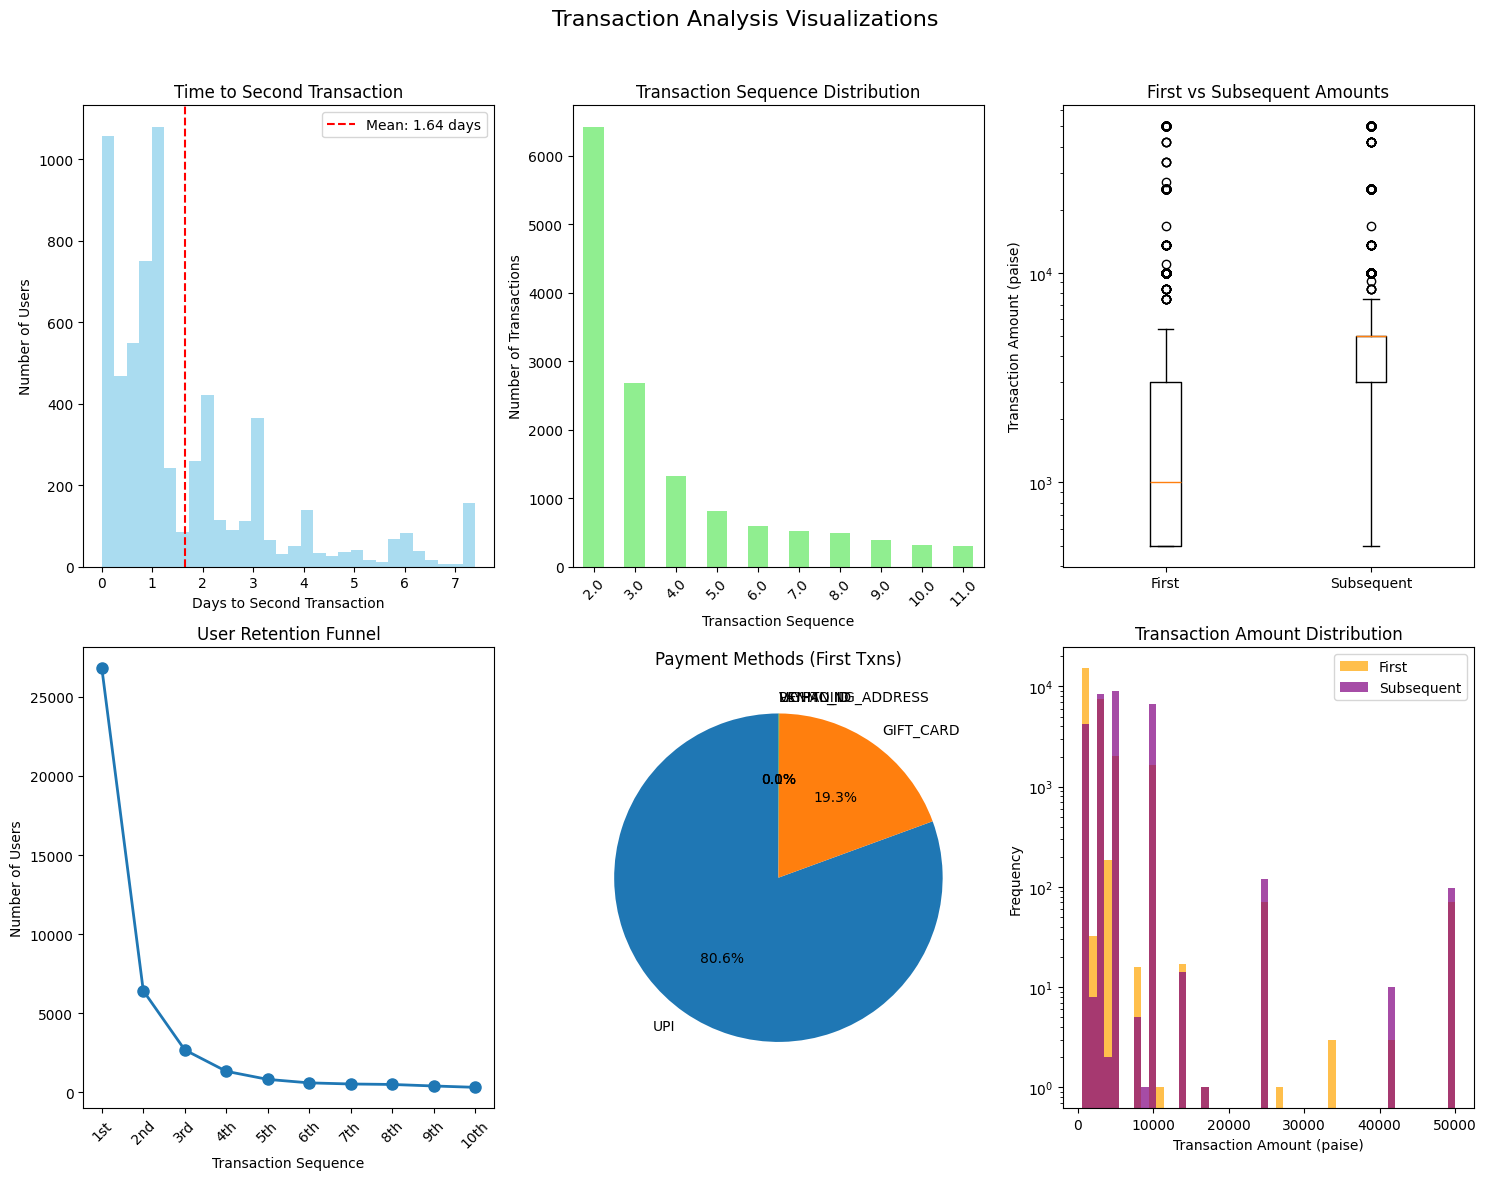

In [31]:
plt.figure(figsize=(15,12))
plt.suptitle("Transaction Analysis Visualizations", fontsize=16)

plt.subplot(2, 3, 1)
if not time_to_second.empty:
  time_to_second_capped = time_to_second[time_to_second['time_diff_days'] <= 30]
  plt.hist(time_to_second_capped['time_diff_days'], bins=30, alpha=0.7, color='skyblue')
  plt.axvline(time_to_second['time_diff_days'].mean(), color='red', linestyle='--',
                    label=f'Mean: {time_to_second["time_diff_days"].mean():.2f} days')
  plt.legend()
else:
    plt.text(0.5, 0.5, 'No second transactions found', ha='center', va='center', transform=plt.gca().transAxes, wrap=True)

plt.xlabel('Days to Second Transaction')
plt.ylabel('Number of Users')
plt.title('Time to Second Transaction')

plt.subplot(2, 3, 2)
if not subsequent_txns.empty:
    sequence_dist = subsequent_txns['transaction_sequence'].value_counts().sort_index()
    sequence_dist.head(10).plot(kind='bar', color='lightgreen')
    plt.xticks(rotation=45)
else:
    plt.text(0.5, 0.5, 'No subsequent transactions found', ha='center', va='center', transform=plt.gca().transAxes, wrap=True)

plt.xlabel('Transaction Sequence')
plt.ylabel('Number of Transactions')
plt.title('Transaction Sequence Distribution')

plt.subplot(2, 3, 3)
plot_data = []
plot_labels = []
if not first_txns.empty:
   plot_data.append(first_txns['value_in_paise'])
   plot_labels.append('First')
if not subsequent_txns.empty:
   plot_data.append(subsequent_txns['value_in_paise'])
   plot_labels.append('Subsequent')

if plot_data:
   plt.boxplot(plot_data, labels=plot_labels)
   plt.yscale('log')
else:
    plt.text(0.5, 0.5, 'No transactions to compare', ha='center', va='center', transform=plt.gca().transAxes, wrap=True)
plt.ylabel('Transaction Amount (paise)')
plt.title('First vs Subsequent Amounts')

plt.subplot(2, 3, 4)
if not first_txns.empty:
    first_count = len(first_txns)
    sequence_counts = subsequent_txns['transaction_sequence'].value_counts().sort_index()
    funnel_data = [first_count] + sequence_counts.head(9).tolist()
    funnel_labels = ['1st'] + [f'{i}nd' if i==2 else f'{i}rd' if i==3 else f'{i}th' for i in range(2, len(funnel_data) + 1)]
    plt.plot(funnel_labels, funnel_data, marker='o', linewidth=2, markersize=8)
    plt.xticks(rotation=45)
else:
    plt.text(0.5, 0.5, 'No first transactions found', ha='center', va='center', transform=plt.gca().transAxes, wrap=True)
plt.xlabel('Transaction Sequence')
plt.ylabel('Number of Users')
plt.title('User Retention Funnel')

plt.subplot(2, 3, 5)
if not first_txns.empty:
     payment_methods = first_txns['payment_method'].value_counts().head(8)
     if not payment_methods.empty:
         plt.pie(payment_methods.values, labels=payment_methods.index, autopct='%1.1f%%', startangle=90)
     else:
         plt.text(0.5, 0.5, 'No payment methods found', ha='center', va='center', transform=plt.gca().transAxes, wrap=True)
else:
      plt.text(0.5, 0.5, 'No first transactions found', ha='center', va='center', transform=plt.gca().transAxes, wrap=True)
plt.title('Payment Methods (First Txns)')

plt.subplot(2, 3, 6)
plotted = False
if not first_txns.empty:
   plt.hist(first_txns['value_in_paise'], bins=50, alpha=0.7, color='orange', label='First')
   plotted = True
   if not subsequent_txns.empty:
      plt.hist(subsequent_txns['value_in_paise'], bins=50, alpha=0.7, color='purple', label='Subsequent')
      plotted = True

if plotted:
    plt.legend()
    plt.yscale('log')
else:
    plt.text(0.5, 0.5, 'No transaction data', ha='center', va='center', transform=plt.gca().transAxes, wrap=True)
plt.xlabel('Transaction Amount (paise)')
plt.ylabel('Frequency')
plt.title('Transaction Amount Distribution')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()